Universidade do Vale do Itajaí<br>
Escola Politécnica<br>
Processamento Digital de Imagens

# Exercício Segmentação Clássica - Sem Deep Learning

### Tutoriais da OpenCV

- https://docs.opencv.org/master/d9/df8/tutorial_root.html
- https://www.geeksforgeeks.org/opencv-python-tutorial/

# Importando bibliotecas necessárias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Segmentação por crescimento de regiões.


## Entradas:    
 - image : np.ndarray - Imagem em níveis de cinza.
 - seeds : list (preferencialmente) of tuples - Lista com pixels sementes [(linha, coluna), ...].
 - threshold : int ou float - Diferença máxima permitida entre o pixel vizinho e a média da região.
    

## Saída:
 - labels : np.ndarray - Imagem rotulada com as regiões segmentadas.

A função region_growing() implementa o algoritmo de crescimento por regiões (Region Growing), usado em segmentação de imagens.

A ideia é:
 - Escolher um ou mais pixels iniciais (sementes).
 - Verificar os pixels vizinhos.
 - Se o vizinho for semelhante à região, ele é incorporado.
 - O processo continua até que não existam mais vizinhos compatíveis.

### Inicialização

rows, cols = image.shape<br>
labels = np.zeros((rows, cols), dtype=np.int32)

O que acontece?
 - rows, cols: obtém o número de linhas e colunas da imagem.
 - labels: cria uma matriz do mesmo tamanho da imagem, inicialmente com zeros.

A matriz labels armazenará o rótulo de cada região:
 - 0 -> pixel ainda não pertence a nenhuma região.
 - 1 -> pertence à região 1.
 - 2 -> pertence à região 2.
 - etc.

### Definição de Vizinhança
neighbors = [(-1, -1), (-1, 0), (-1, 1),( 0, -1), ( 0, 0) ,( 0, 1),( 1, -1), ( 1, 0), ( 1, 1)]<br>

Define a conectividade-8. Para um pixel (x, y), serão analisados 8 vizinhos:
 - cima
 - baixo
 - esquerda
 - direita
 - diagonais

### Inicialização do identificador da região
region_id = 1<br>

A primeira região receberá o rótulo 1.<br>

### Percorre cada semente
for seed in seeds:<br>
 - A função pode trabalhar com várias sementes.<br>

Exemplo:<br>
 - seeds = [(1,1), (1,5)]<br>

#### Obtém a posição da semente
r, c = seed

#### Verifica se já foi rotulada

if labels[r, c] != 0:<br>
    continue<br>
  
 - Se a semente já pertence a alguma região, ela é ignorada.

#### Inicializa a fila

queue = deque()<br>
queue.append((r, c))<br>
labels[r, c] = region_id<br>

Explicação
 - Cria uma fila FIFO.
 - Insere a semente.
 - Marca a semente com o rótulo da região.

#### Inicializa estatísticas da região

region_pixels = [image[r, c]]<br>
region_mean = float(image[r, c])<br>

- Exemplo
 - Se a semente tiver valor 2:

region_pixels = [2]<br>
region_mean = 2.0

In [ ]:
def region_growing(image, seeds, threshold):
    rows, cols = image.shape
    labels = np.zeros((rows, cols), dtype=np.int32)
    
    # Conectividade-8 - Pense nessa parte como uma janela de kernel, onde o (0,0) é o pixel central
    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 ( 0, -1),          ( 0, 1),
                 ( 1, -1), ( 1, 0), ( 1, 1)]
    
    region_id = 1

    for seed in seeds:
        r, c = seed
        
        if labels[r, c] != 0: # Ignora se já foi rotulado
            continue
        
       
        queue = deque()  # Inicializa fila
        queue.append((r, c))
        labels[r, c] = region_id
        
        
        region_pixels = [image[r, c]] # Estatísticas da região
        region_mean = float(image[r, c])

        while queue:
            x, y = queue.popleft()

            for dx, dy in neighbors:
                nx, ny = x + dx, y + dy

                if 0 <= nx < rows and 0 <= ny < cols: # Verifica limites
                    if labels[nx, ny] == 0:  # Se ainda não foi rotulado
                        if abs(float(image[nx, ny]) - region_mean) < threshold: # Critério de similaridade
                            labels[nx, ny] = region_id
                            queue.append((nx, ny))

                            region_pixels.append(image[nx, ny]) # Atualiza média da região
                            region_mean = np.mean(region_pixels)
        region_id += 1
    return labels

## Entada: Exemplo da figura do slide da aula

In [3]:
img = np.array([
    [2, 0, 1, 0, 3, 7, 7, 8],
    [0, 2, 1, 3, 5, 8, 9, 9],
    [1, 0, 0, 2, 7, 9, 7, 8],
    [2, 3, 0, 7, 8, 7, 8, 8],
    [1, 3, 2, 7, 7, 8, 7, 7],
    [0, 0, 0, 2, 3, 7, 8, 8]
], dtype=np.uint8)

# Sementes destacadas na figura:
# valor 2 na posição (1,1)
# valor 8 na posição (1,5)
seeds = [(1, 1), (1, 5)]

## Execução

In [4]:
# Segmentação com limiar < 4
labels_t4 = region_growing(img, seeds, threshold=4)

# Segmentação com limiar < 8
labels_t8 = region_growing(img, seeds, threshold=8)

print("Imagem original:")
print(img)

print("\nSegmentação com threshold < 4:")
print(labels_t4)

print("\nSegmentação com threshold < 8:")
print(labels_t8)

Imagem original:
[[2 0 1 0 3 7 7 8]
 [0 2 1 3 5 8 9 9]
 [1 0 0 2 7 9 7 8]
 [2 3 0 7 8 7 8 8]
 [1 3 2 7 7 8 7 7]
 [0 0 0 2 3 7 8 8]]

Segmentação com threshold < 4:
[[1 1 1 1 1 2 2 2]
 [1 1 1 1 1 2 2 2]
 [1 1 1 1 2 2 2 2]
 [1 1 1 2 2 2 2 2]
 [1 1 1 2 2 2 2 2]
 [1 1 1 1 1 2 2 2]]

Segmentação com threshold < 8:
[[1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]]


## Vizualizando 

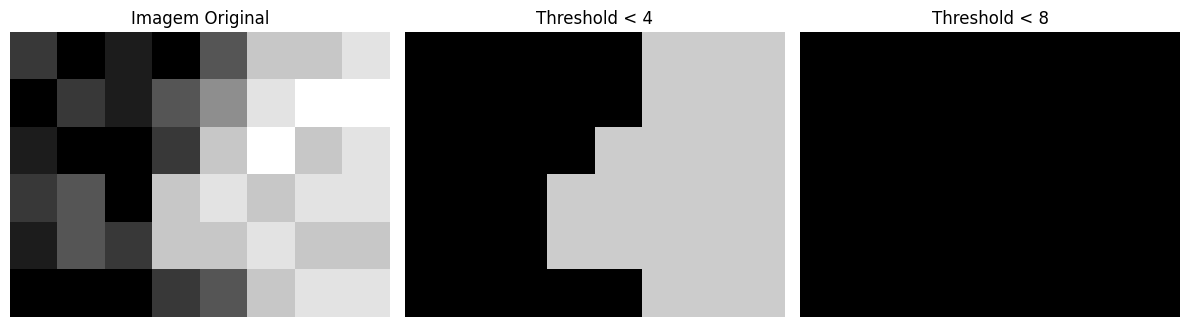

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Imagem Original")

axes[1].imshow(labels_t4, cmap='nipy_spectral')
axes[1].set_title("Threshold < 4")

axes[2].imshow(labels_t8, cmap='nipy_spectral')
axes[2].set_title("Threshold < 8")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()